In [1]:
!pip install shap -q

In [2]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaConfig, RobertaForSequenceClassification
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
import os
import random
import re
import shap
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split


# 1. DATASET PREPARATION & CLEANING

In [3]:
df = pd.read_csv('datasetnad_latest.csv')
def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = text.lower()
    words = text.split()

    return " ".join(words)

df['clean_text'] = df['text'].apply(preprocess_text)
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['text'])
similarity_matrix = cosine_similarity(tfidf_matrix)

threshold = 0.95
to_remove = set()

for i in range(len(df)):
    for j in range(i + 1, len(df)):
        if similarity_matrix[i, j] > threshold:
            to_remove.add(j)

df_cleaned = df.drop(list(to_remove)).reset_index(drop=True)
print("\nOriginal size:", len(df))
print("After removing near-duplicates:", len(df_cleaned))



Original size: 2600
After removing near-duplicates: 2540


In [4]:
# PRINT RANDOM SAMPLES
print("\nSAMPLE CLEANED TEXT:\n")

for i in range(5):
    print("=" * 60)
    print("Original :", df_cleaned.iloc[i]['text'])
    print("Cleaned  :", df_cleaned.iloc[i]['clean_text'])


SAMPLE CLEANED TEXT:

Original : I feel like I might disappear forever.
Cleaned  : i feel like i might disappear forever.
Original : The thought of wanting to disappear forever keeps coming back.
Cleaned  : the thought of wanting to disappear forever keeps coming back.
Original : I am scared because part of me wants to disappear forever.
Cleaned  : i am scared because part of me wants to disappear forever.
Original : Everything feels unbearable and I want to disappear forever.
Cleaned  : everything feels unbearable and i want to disappear forever.
Original : I keep imagining what it would be like to disappear forever.
Cleaned  : i keep imagining what it would be like to disappear forever.


In [5]:
duplicates_data = []

for i in range(len(df)):
    for j in range(i + 1, len(df)):
        if similarity_matrix[i, j] > threshold:
            duplicates_data.append({
                "keyword" : df.iloc[i]['keyword'],
                "index_1": i,
                "text_1": df.iloc[i]['text'],
                "index_2": j,
                "text_2": df.iloc[j]['text'],
                "similarity": similarity_matrix[i, j]
            })

duplicates_df = pd.DataFrame(duplicates_data)
duplicates_df.to_csv("duplicates_found.csv", index=False)

print("Saved duplicates to duplicates_found.csv")

Saved duplicates to duplicates_found.csv


In [6]:
print(df_cleaned.columns)

print("\nLabel distribution:")
print(df['label'].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

Index(['id', 'text', 'keyword', 'label', 'category', 'clean_text'], dtype='object')

Label distribution:
label
risky        1300
non-risky    1300
Name: count, dtype: int64

Missing values:
id            0
text          0
keyword       0
label         0
category      0
clean_text    0
dtype: int64


In [7]:
df_train, df_temp = train_test_split(df_cleaned,test_size=0.30,random_state=42,stratify=df_cleaned['label'])
df_val, df_test = train_test_split(df_temp,test_size=0.50,random_state=42,stratify=df_temp['label'])

print(f"Training data shape: {df_train.shape}")
print(f"Validation data shape: {df_val.shape}")
print(f"Test data shape: {df_test.shape}")


Training data shape: (1778, 6)
Validation data shape: (381, 6)
Test data shape: (381, 6)


Train label distribution:
 label
risky        906
non-risky    872
Name: count, dtype: int64

Val label distribution:
 label
risky        194
non-risky    187
Name: count, dtype: int64

Test label distribution:
 label
risky        194
non-risky    187
Name: count, dtype: int64
Number of unique label: 2
Unique label: ['risky' 'non-risky']


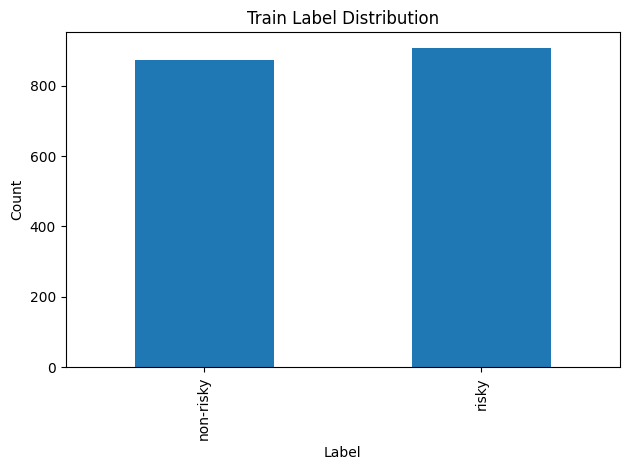

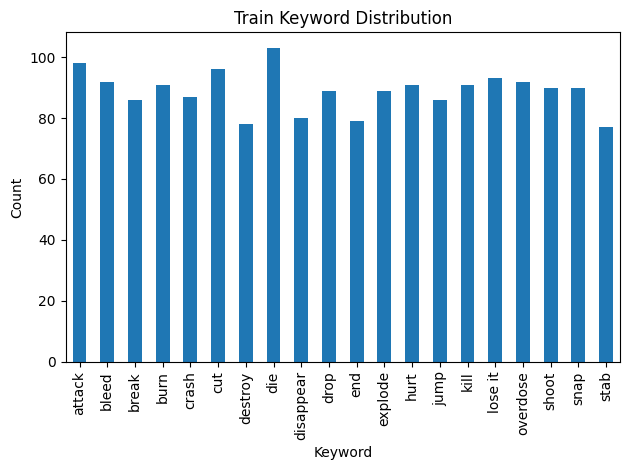

In [8]:
print("Train label distribution:\n", df_train['label'].value_counts())
print("\nVal label distribution:\n", df_val['label'].value_counts())
print("\nTest label distribution:\n", df_test['label'].value_counts())

unique_intents = df_train['label'].unique()
num_unique_intents = df_train['label'].nunique()

print(f"Number of unique label: {num_unique_intents}")
print(f"Unique label: {unique_intents}")

df_train.groupby('label').size().plot.bar()

plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Train Label Distribution')

plt.tight_layout()
plt.show()

df_train.groupby('keyword').size().plot.bar()

plt.xlabel('Keyword')
plt.ylabel('Count')
plt.title('Train Keyword Distribution')

plt.tight_layout()
plt.show()

In [9]:
# LONGEST text
longest_idx = df_train['clean_text'].str.len().idxmax()
longest_text = df_train.loc[longest_idx, 'clean_text']

print("Longest text:")
print(longest_text)
print("Length:", len(longest_text))


# SHORTEST text
shortest_idx = df_train['clean_text'].str.len().idxmin()
shortest_text = df_train.loc[shortest_idx, 'clean_text']

print("\nShortest text:")
print(shortest_text)
print("Length:", len(shortest_text))

Longest text:
i do not want danger; i want to stay safe instead of trying to destroy myself or everything around me.
Length: 102

Shortest text:
i will not die.
Length: 15


In [10]:
# Encode labels
label_encoder = LabelEncoder()

df_train['encoded_label'] = label_encoder.fit_transform(df_train['label'])
df_val['encoded_label'] = label_encoder.transform(df_val['label'])
df_test['encoded_label'] = label_encoder.transform(df_test['label'])

# Split into arrays
train_texts = df_train['clean_text'].values
train_labels = df_train['encoded_label'].values

val_texts = df_val['clean_text'].values
val_labels = df_val['encoded_label'].values

test_texts = df_test['clean_text'].values
test_labels = df_test['encoded_label'].values

In [11]:
print(df_train['clean_text'].head())

2312    at this moment, i feel like i could stab someone.
2070    i cannot deny that part of me wants to drop fr...
1097    the article mentioned that people can bleed th...
1921    i feel like i may actually break myself beyond...
121     i cannot imagine trying to disappear forever t...
Name: clean_text, dtype: object


In [12]:
class IntentDataset(Dataset):
    def __init__(self, texts, intents, tokenizer, max_len=64):
        self.texts = texts
        self.intents = intents
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        intent = self.intents[idx]

        # TOKENIZATION text using the tokenizer's __call__ method for proper encoding
        encoding = self.tokenizer(text,add_special_tokens=True,max_length=self.max_len,padding='max_length',
            truncation=True,return_attention_mask=True,return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'intent': torch.tensor(intent, dtype=torch.long)
        }

In [13]:
def evaluate_model(model, data_loader, device, title="Test"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["intent"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')

    print(f"\n--- {title} Results ---")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 (macro): {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds))

    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

print("evaluate_model defined!")

evaluate_model defined!


In [14]:
from types import SimpleNamespace

configss = SimpleNamespace(max_len=64,batch_size=16,learning_rate=2e-5,num_epochs=5,
    dropout=0.3, patience=3, random_seed=42,model_name="roberta-base")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [15]:
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(configss.random_seed)
np.random.seed(configss.random_seed)

# Initialize tokenizer
tokenizer = RobertaTokenizer.from_pretrained(configss.model_name)

# Create datasets
train_dataset = IntentDataset(train_texts, train_labels, tokenizer)
val_dataset = IntentDataset(val_texts, val_labels, tokenizer)
test_dataset = IntentDataset(test_texts, test_labels, tokenizer)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=configss.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=configss.batch_size)
test_loader = DataLoader(test_dataset, batch_size=configss.batch_size)
print("test_loader ready!")

test_loader ready!


# 2. Without fine-tuning RoBERTa

In [16]:
from transformers import RobertaConfig, RobertaForSequenceClassification

class PretrainedOnlyClassifier(nn.Module):
    def __init__(self, num_intent_classes):
        super(PretrainedOnlyClassifier, self).__init__()
        # THIS is the only difference — .from_pretrained() loads real weights
        self.model = RobertaForSequenceClassification.from_pretrained(
            "roberta-base",
            num_labels=num_intent_classes,
            hidden_dropout_prob=configss.dropout
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.logits

pretrained_only = PretrainedOnlyClassifier(num_intent_classes=num_unique_intents)
pretrained_only = pretrained_only.to(device)

print("Pretrained-only classifier ready — knows English, but NOT fine-tuned on your data!")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Pretrained-only classifier ready — knows English, but NOT fine-tuned on your data!


In [17]:
# Evaluate random model with NO training at all
print("=" * 50)
print("EXPERIMENT 1: Pretrained-Only")
print("=" * 50)

pretrained_only_results = evaluate_model(
    pretrained_only,
    test_loader,
    device,
    title="Pretrained Only — No Fine-Tuning"
)

EXPERIMENT 1: Pretrained-Only

--- Pretrained Only — No Fine-Tuning Results ---
Accuracy  : 0.4908
Precision : 0.2454
Recall    : 0.5000
F1 (macro): 0.3292

Classification Report:
              precision    recall  f1-score   support

           0       0.49      1.00      0.66       187
           1       0.00      0.00      0.00       194

    accuracy                           0.49       381
   macro avg       0.25      0.50      0.33       381
weighted avg       0.24      0.49      0.32       381



In [18]:
def predict_pretrained_only(text, tokenizer, label_encoder, device):
    pretrained_only.eval()
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=configss.max_len,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        logits = pretrained_only(input_ids=input_ids, attention_mask=attention_mask)
        pred = torch.argmax(logits, dim=1).item()

    return label_encoder.inverse_transform([pred])[0]

# Test sentences
sample_texts = [
    "I want to die",
    "I want to die of embarrassment",
    "I want to jump from this building",
    "I want to jump out of excitement",
    "I'm dying of laughter",
    "I want to cut myself",
    "I need to cut my hair",
]

print("=" * 55)
print("PRETRAINED ONLY — No Fine-Tuning — Sample Predictions")
print("=" * 55)
for text in sample_texts:
    pred = predict_pretrained_only(text, tokenizer, label_encoder, device)
    print(f"'{text}'")
    print(f"  → {pred}\n")

PRETRAINED ONLY — No Fine-Tuning — Sample Predictions
'I want to die'
  → non-risky

'I want to die of embarrassment'
  → non-risky

'I want to jump from this building'
  → non-risky

'I want to jump out of excitement'
  → non-risky

'I'm dying of laughter'
  → non-risky

'I want to cut myself'
  → non-risky

'I need to cut my hair'
  → non-risky



In [19]:
# SHAP for Pretrained Only (No Fine-Tuning) — waterfall style
def predict_proba_pretrained_only(texts):
    pretrained_only.eval()
    probs_all = []

    for text in texts:
        cleaned = preprocess_text(text)
        encoding = tokenizer(
            cleaned,
            add_special_tokens=True,
            max_length=configss.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        with torch.no_grad():
            logits = pretrained_only(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

        probs_all.append(probs)

    return np.array(probs_all)

explainer_pretrained_only = shap.Explainer(predict_proba_pretrained_only, tokenizer)
print("SHAP explainer ready!")

SHAP explainer ready!


Sentence: I always cut myself because it gives me pleasure.
Predicted risky probability: 0.4366


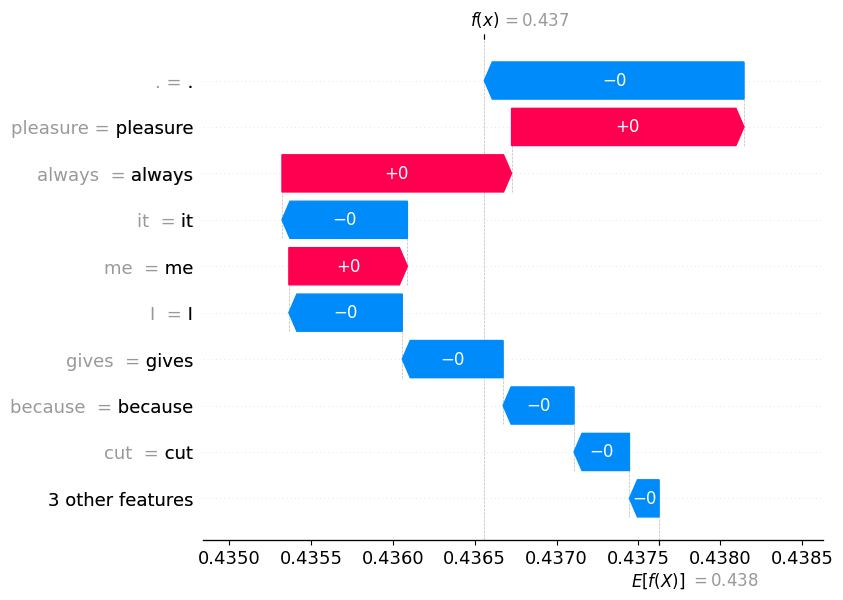

In [20]:
single_text = ["I always cut myself because it gives me pleasure."]
single_shap_pretrained = explainer_pretrained_only(single_text)

print("Sentence:", single_text[0])
print(f"Predicted risky probability: {single_shap_pretrained[0, :, 1].base_values + single_shap_pretrained[0, :, 1].values.sum():.4f}")

shap.plots.waterfall(single_shap_pretrained[0, :, 1], max_display=10)

Sentence: I stop cutting myself after I see my therapist.
Predicted risky probability: 0.4330


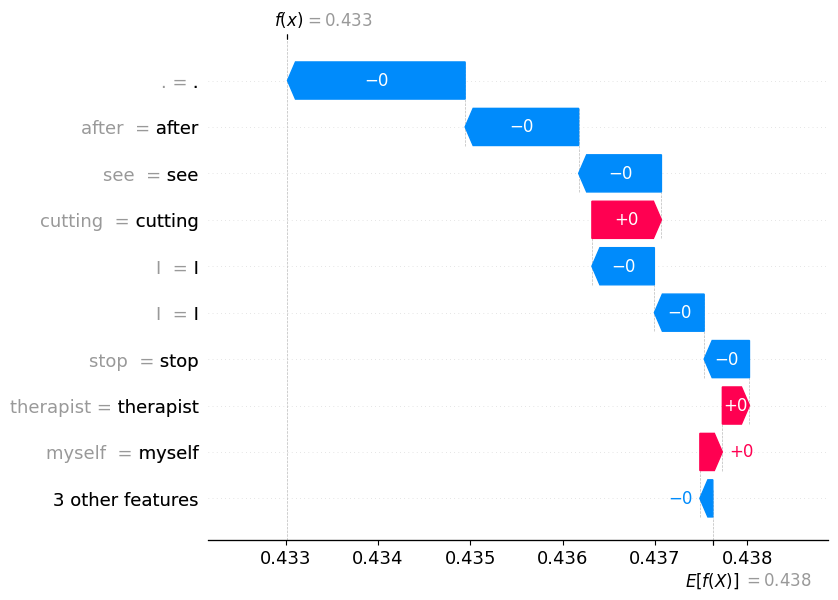

In [21]:
single_text = ["I stop cutting myself after I see my therapist."]
single_shap_pretrained = explainer_pretrained_only(single_text)

print("Sentence:", single_text[0])
print(f"Predicted risky probability: {single_shap_pretrained[0, :, 1].base_values + single_shap_pretrained[0, :, 1].values.sum():.4f}")

shap.plots.waterfall(single_shap_pretrained[0, :, 1], max_display=10)

# 2. Fine-Tuning RoBERTa

Text → Tokenizer → RoBERTa → [CLS] → Linear layer → Prediction

In [22]:
from transformers import RobertaForSequenceClassification, RobertaConfig

class IntentClassifier(nn.Module):
    def __init__(self, num_intent_classes, model_name=configss.model_name, dropout=configss.dropout):
        super(IntentClassifier, self).__init__()
        self.model = RobertaForSequenceClassification.from_pretrained(
            model_name,
            num_labels=num_intent_classes,
            hidden_dropout_prob=dropout
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.logits  # returns logits directly

model = IntentClassifier(num_intent_classes=num_unique_intents)
model = model.to(device)
print("IntentClassifier ready!")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


IntentClassifier ready!


In [23]:
def train_model(model, train_loader, val_loader, device, num_epochs=configss.num_epochs):
    optimizer = torch.optim.AdamW(model.parameters(), lr=configss.learning_rate, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    best_val_accuracy = 0
    best_model = None
    epochs_without_improvement = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        correct_predictions = 0
        total_predictions = 0

        for i, batch in enumerate(train_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            intents = batch['intent'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, intents)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_predictions += (predicted == intents).sum().item()
            total_predictions += intents.size(0)

            # prints on same line
            print(f"  Epoch {epoch+1}/{num_epochs} | Batch {i+1}/{len(train_loader)} | Loss: {total_loss/(i+1):.4f}", end='\r')

        train_loss = total_loss / len(train_loader)
        train_accuracy = correct_predictions / total_predictions

        # validation
        model.eval()
        val_correct = 0
        val_total = 0
        val_loss_total = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                intents = batch['intent'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs, intents)
                val_loss_total += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == intents).sum().item()
                val_total += intents.size(0)

        val_loss = val_loss_total / len(val_loader)
        val_accuracy = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        # prints full summary after each epoch
        print(f"\nEpoch {epoch+1}/{num_epochs} done! "
              f"Train Loss={train_loss:.4f} | "
              f"Val Loss={val_loss:.4f} | "
              f"Train Acc={train_accuracy:.4f} | "
              f"Val Acc={val_accuracy:.4f}")

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_model = model.state_dict().copy()
            epochs_without_improvement = 0
            print(f"  ✓ New best model saved! Val Acc={val_accuracy:.4f}")
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= configss.patience:
            print(f"Early stopping triggered after {configss.patience} epochs without improvement.")
            break

        scheduler.step()

    return best_model, best_val_accuracy, history

print("train_model defined!")

train_model defined!


In [24]:
def predict_intent(text, model, tokenizer, intent_encoder, device, max_len=configss.max_len):
    processed_text = preprocess_text(text)
    model.eval()
    encoding = tokenizer(
        processed_text,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, predicted = torch.max(outputs, 1)  # outputs is already logits
        predicted_intent = intent_encoder.inverse_transform([predicted.item()])[0]

    return predicted_intent

print("predict_intent defined!")

predict_intent defined!


In [25]:
for i in range(3):
    sample = train_dataset[i]
    print("=" * 50)
    print(f"Sample {i}")
    print("Text:", train_texts[i])
    print("Label:", train_labels[i])
    print("Input IDs:", sample['input_ids'][:10])

    decoded = tokenizer.decode(sample['input_ids'])
    print("Decoded:", decoded)

Sample 0
Text: at this moment, i feel like i could stab someone.
Label: 1
Input IDs: tensor([   0,  415,   42, 1151,    6,  939,  619,  101,  939,  115])
Decoded: <s>at this moment, i feel like i could stab someone.</s><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad>
Sample 1
Text: i cannot deny that part of me wants to drop from a high place.
Label: 1
Input IDs: tensor([   0,  118, 1395, 7631,   14,  233,    9,  162, 1072,    7])
Decoded: <s>i cannot deny that part of me wants to drop from a high place.</s><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad>
Sample 2
Text: the article mentioned that people 

In [26]:
model_path = 'best_model.pth'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = IntentClassifier(num_intent_classes=num_unique_intents)
model = model.to(device)

best_model_state, best_accuracy, history = train_model(
    model, train_loader, val_loader, device
)

torch.save({
    'model_state_dict': best_model_state,
    'accuracy': best_accuracy,
    'history': history
}, model_path)

print(f"\nBest validation accuracy: {best_accuracy:.4f}")
print("Model saved to best_model.pth!")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/5 done! Train Loss=0.5028 | Val Loss=0.0121 | Train Acc=0.7261 | Val Acc=1.0000
  ✓ New best model saved! Val Acc=1.0000

Epoch 2/5 done! Train Loss=0.0643 | Val Loss=0.0001 | Train Acc=0.9837 | Val Acc=1.0000

Epoch 3/5 done! Train Loss=0.0169 | Val Loss=0.0001 | Train Acc=0.9961 | Val Acc=1.0000

Epoch 4/5 done! Train Loss=0.0130 | Val Loss=0.0000 | Train Acc=0.9972 | Val Acc=1.0000
Early stopping triggered after 3 epochs without improvement.

Best validation accuracy: 1.0000
Model saved to best_model.pth!


In [27]:
model.eval()
with torch.no_grad():
    sample = train_dataset[0]
    outputs = model.model.roberta(
        input_ids=sample['input_ids'].unsqueeze(0).to(device),
        attention_mask=sample['attention_mask'].unsqueeze(0).to(device)
    )
    cls_embedding = outputs.last_hidden_state[:, 0, :]

print("Embedding shape:", cls_embedding.shape)
print("First 10 values:", cls_embedding[0][:10])

Embedding shape: torch.Size([1, 768])
First 10 values: tensor([ 0.1247, -0.6559, -0.0889,  0.3504,  1.8032,  0.4261, -0.6903,  1.1421,
         0.0505, -0.3766], device='cuda:0')


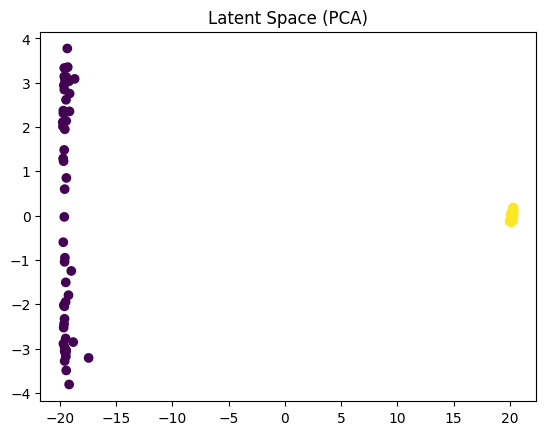

In [28]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

embeddings = []
labels = []

model.eval()

for i in range(100):  # small subset
    sample = train_dataset[i]

    with torch.no_grad():
        outputs = model.model.roberta(
            input_ids=sample['input_ids'].unsqueeze(0).to(device),
            attention_mask=sample['attention_mask'].unsqueeze(0).to(device)
        )
        cls_emb = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()

    embeddings.append(cls_emb)
    labels.append(sample['intent'].item())

# Reduce to 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

# Plot
plt.scatter(reduced[:, 0], reduced[:, 1], c=labels)
plt.title("Latent Space (PCA)")
plt.show()

In [29]:
# @title only for evaluation


model_path = 'best_model.pth'

best_model_state, best_accuracy, history = train_model(model, train_loader, val_loader, device)

torch.save(
    {
        'model_state_dict': best_model_state,
        'accuracy': best_accuracy,
        #'model_configs': model.configs.to_dict(),
        'history': history
    },
    model_path
)


Epoch 1/5 done! Train Loss=0.0969 | Val Loss=0.0000 | Train Acc=0.9848 | Val Acc=1.0000
  ✓ New best model saved! Val Acc=1.0000

Epoch 2/5 done! Train Loss=0.0241 | Val Loss=0.0000 | Train Acc=0.9961 | Val Acc=1.0000

Epoch 3/5 done! Train Loss=0.0037 | Val Loss=0.0000 | Train Acc=0.9994 | Val Acc=1.0000

Epoch 4/5 done! Train Loss=0.0035 | Val Loss=0.0000 | Train Acc=0.9994 | Val Acc=1.0000
Early stopping triggered after 3 epochs without improvement.


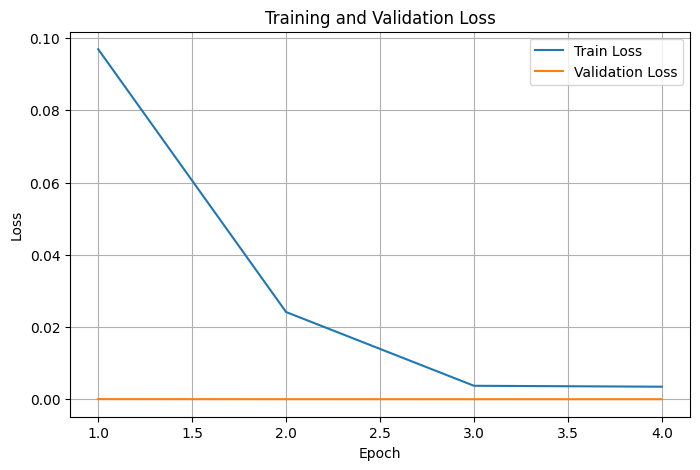

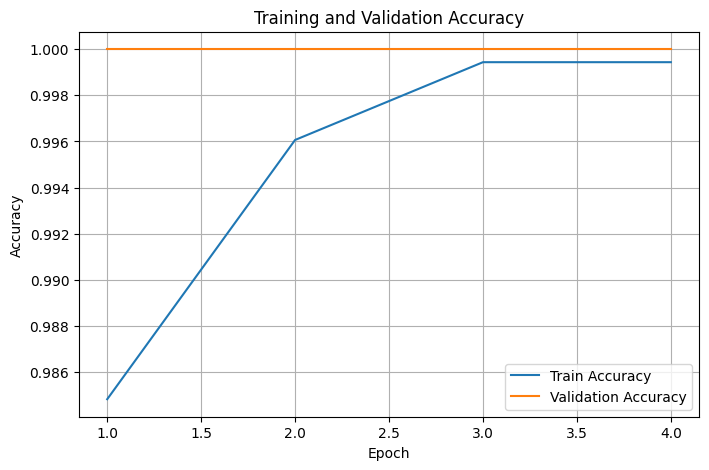

In [30]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_accuracy"], label="Train Accuracy")
plt.plot(epochs, history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
checkpoint = torch.load("best_model.pth", map_location=device)

model = IntentClassifier(num_intent_classes=num_unique_intents).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded trained model successfully")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded trained model successfully


In [32]:
def load_model(model, save_path, device):
    if os.path.exists(save_path):
        # Load the saved state
        checkpoint = torch.load(save_path, map_location=device)

        # Load state dict into model
        model.load_state_dict(checkpoint['model_state_dict'])

        # Return the accuracy achieved
        return checkpoint.get('accuracy', None), checkpoint.get('history', None)
    else:
        print(f"No saved model found at {save_path}")
        return None, None

In [33]:
# Load best model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device {device}")

model = IntentClassifier(num_intent_classes=num_unique_intents).to(device)
model_path = 'best_model.pth'
best_accuracy, history = load_model(model, model_path, device)

print(f"Loaded model with accuracy: {best_accuracy}")
model.eval()

Device cuda


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded model with accuracy: 1.0


IntentClassifier(
  (model): RobertaForSequenceClassification(
    (roberta): RobertaModel(
      (embeddings): RobertaEmbeddings(
        (word_embeddings): Embedding(50265, 768, padding_idx=1)
        (token_type_embeddings): Embedding(1, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (position_embeddings): Embedding(514, 768, padding_idx=1)
      )
      (encoder): RobertaEncoder(
        (layer): ModuleList(
          (0-11): 12 x RobertaLayer(
            (attention): RobertaAttention(
              (self): RobertaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): RobertaSelfOutput(
                (dense

# Evaluation ID & OOD Test

In [34]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, data_loader, device, title="Test"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["intent"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted'
    )

    print(f"{title} Accuracy:  {acc:.4f}")
    print(f"{title} Precision: {precision:.4f}")
    print(f"{title} Recall:    {recall:.4f}")
    print(f"{title} F1 Score:  {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - {title}")
    plt.show()

    return acc, precision, recall, f1

Evaluation ID Test
ID Test Accuracy:  1.0000
ID Test Precision: 1.0000
ID Test Recall:    1.0000
ID Test F1 Score:  1.0000

Classification Report:
              precision    recall  f1-score   support

   non-risky       1.00      1.00      1.00       187
       risky       1.00      1.00      1.00       194

    accuracy                           1.00       381
   macro avg       1.00      1.00      1.00       381
weighted avg       1.00      1.00      1.00       381



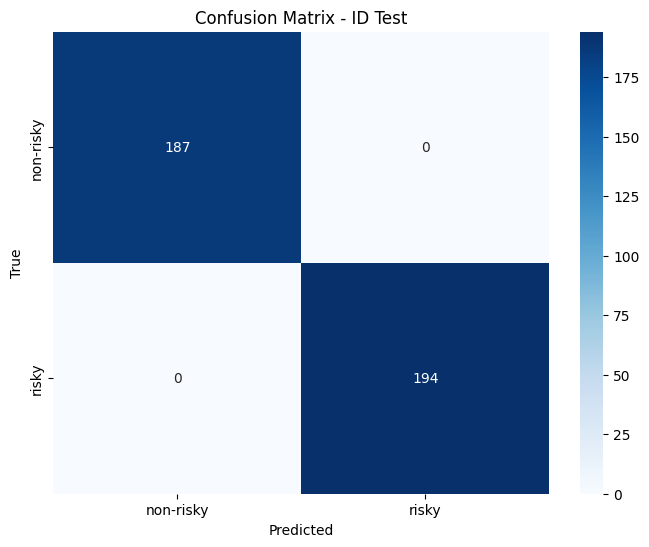

In [35]:
# Evaluation ID Test

print("=" * 50)
print("Evaluation ID Test")
print("=" * 50)
id_results = evaluate_model(model, test_loader, device, title="ID Test")

Evaluation OOD Test
OOD Test Accuracy:  0.5600
OOD Test Precision: 0.5586
OOD Test Recall:    0.5600
OOD Test F1 Score:  0.5589

Classification Report:
              precision    recall  f1-score   support

   non-risky       0.58      0.61      0.60        80
       risky       0.53      0.50      0.51        70

    accuracy                           0.56       150
   macro avg       0.56      0.56      0.56       150
weighted avg       0.56      0.56      0.56       150



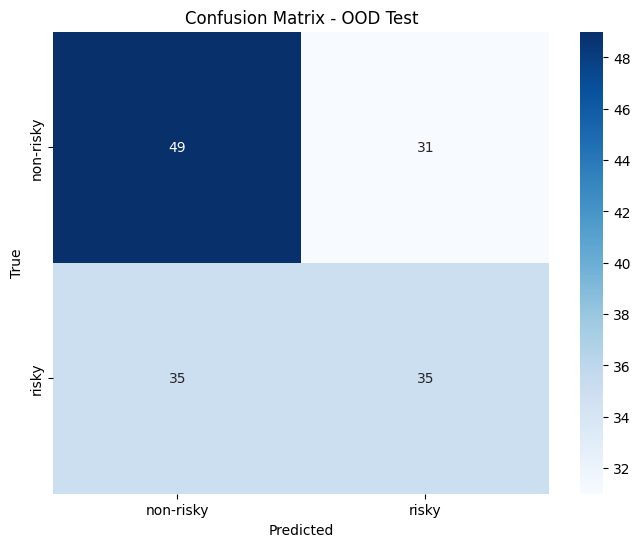

In [36]:
# Evaluation OOD Test
import os
import pandas as pd

ood_path = "custom_ood_set_150.csv"

if os.path.exists(ood_path):
    df_ood = pd.read_csv(ood_path)

    df_ood["clean_text"] = df_ood["text"].apply(preprocess_text)
    df_ood["encoded_label"] = label_encoder.transform(df_ood["gold_label"])

    ood_texts = df_ood["clean_text"].values
    ood_labels = df_ood["encoded_label"].values

    ood_dataset = IntentDataset(ood_texts, ood_labels, tokenizer)
    ood_loader = DataLoader(ood_dataset, batch_size=configss.batch_size)

    print("=" * 50)
    print("Evaluation OOD Test")
    print("=" * 50)

    ood_results = evaluate_model(model, ood_loader, device, title="OOD Test")

else:
    print("No OOD dataset found yet. True OOD evaluation cannot be performed.")

# OOD Evaluation By category

In [37]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import pandas as pd
import torch

def evaluate_by_category(model, df, tokenizer, device, batch_size):
    category_results = []

    for category in df["category"].unique():
        df_cat = df[df["category"] == category].copy()

        texts = df_cat["clean_text"].values
        labels = df_cat["encoded_label"].values

        dataset = IntentDataset(texts, labels, tokenizer)
        loader = DataLoader(dataset, batch_size=batch_size)

        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                y_true = batch["intent"].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                preds = torch.argmax(outputs, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_true.cpu().numpy())

        acc = accuracy_score(all_labels, all_preds)
        precision, recall, f1, _ = precision_recall_fscore_support(
            all_labels, all_preds, average="weighted", zero_division=0
        )

        category_results.append({
            "category": category,
            "accuracy": acc,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": len(df_cat)
        })

    results_df = pd.DataFrame(category_results)
    return results_df

In [38]:
category_results_df = evaluate_by_category(
    model=model,
    df=df_ood,
    tokenizer=tokenizer,
    device=device,
    batch_size=configss.batch_size
)

print(category_results_df)

            category  accuracy  precision    recall        f1  support
0           negation  0.733333   0.723485  0.733333  0.724868       30
1           temporal  0.333333   0.320574  0.333333  0.321267       30
2  negation_temporal  0.600000   0.619048  0.600000  0.583333       30
3         figurative  0.700000   0.700893  0.700000  0.699666       30
4          ambiguous  0.433333   0.433036  0.433333  0.432703       30


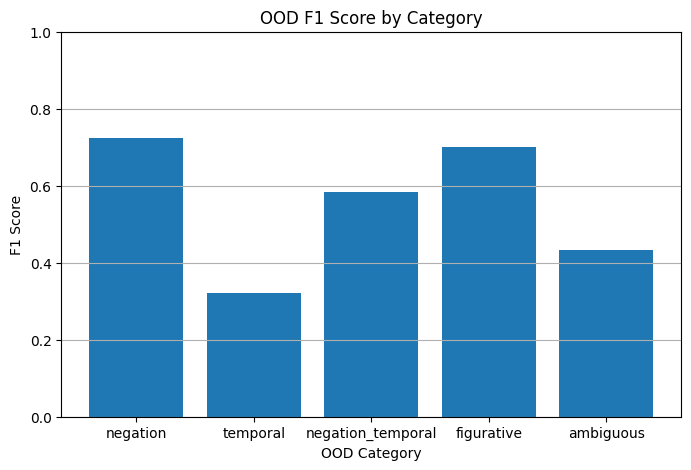

In [39]:
plt.figure(figsize=(8, 5))
plt.bar(category_results_df["category"], category_results_df["f1"])
plt.xlabel("OOD Category")
plt.ylabel("F1 Score")
plt.title("OOD F1 Score by Category")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

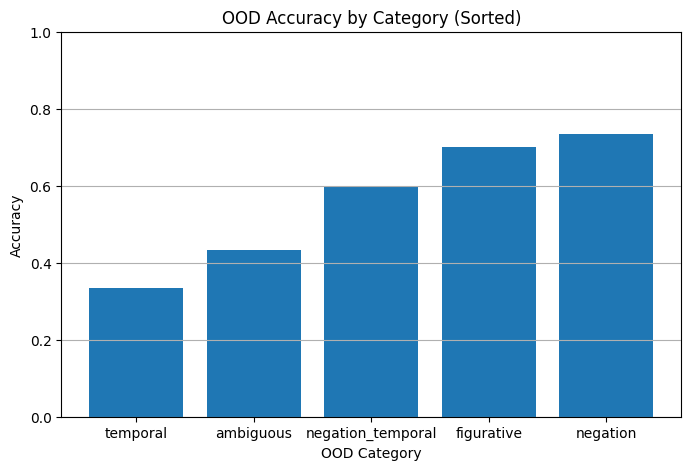

In [40]:
category_results_df = category_results_df.sort_values(by="accuracy")

plt.figure(figsize=(8, 5))
plt.bar(category_results_df["category"], category_results_df["accuracy"])
plt.xlabel("OOD Category")
plt.ylabel("Accuracy")
plt.title("OOD Accuracy by Category (Sorted)")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

# LATENT SPACE AFTER FINE TUNING


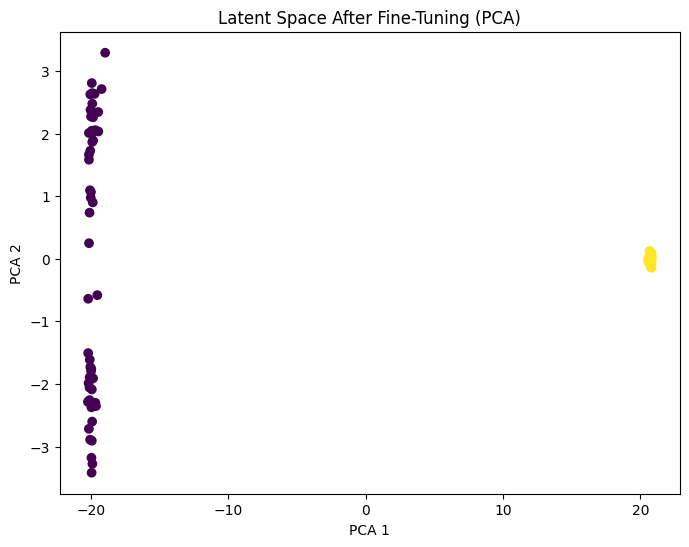

In [41]:
embeddings_after = []
labels_after = []

model.eval()

for i in range(min(100, len(train_dataset))):
    sample = train_dataset[i]

    with torch.no_grad():
        outputs = model.model.roberta(
            input_ids=sample['input_ids'].unsqueeze(0).to(device),
            attention_mask=sample['attention_mask'].unsqueeze(0).to(device)
        )

        cls_emb = outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()

    embeddings_after.append(cls_emb)
    labels_after.append(sample['intent'].item())

pca = PCA(n_components=2)
reduced_after = pca.fit_transform(np.array(embeddings_after))

plt.figure(figsize=(8, 6))
scatter = plt.scatter(reduced_after[:, 0], reduced_after[:, 1], c=labels_after)
plt.title("Latent Space After Fine-Tuning (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [42]:
print(label_encoder.classes_)

['non-risky' 'risky']


In [43]:
# Example prediction
# Get 10 random rows
random_rows = df_test.sample(n=10)  # specifies 10 rows
for index, row in random_rows.iterrows():
    sample_text = row['text']
    predicted_intent = predict_intent(sample_text, model, tokenizer, label_encoder, device)
    result = predicted_intent == row['label']
    print(f"'{sample_text}' \n  > Predicted intent: {predicted_intent} {'- CORRECT' if result else '- Incorrect'}\n")

'We discussed what it means to burn toast in the kitchen.' 
  > Predicted intent: non-risky - CORRECT

'The advertisement used disappear as a playful exaggeration.' 
  > Predicted intent: non-risky - CORRECT

'I cannot stop thinking about how to cut myself this evening.' 
  > Predicted intent: risky - CORRECT

'Before the deadline, I need to drop a course before the deadline.' 
  > Predicted intent: non-risky - CORRECT

'I will not follow any thought that tells me to disappear forever.' 
  > Predicted intent: non-risky - CORRECT

'The speaker used end to describe stress, not actual harm.' 
  > Predicted intent: non-risky - CORRECT

'I cannot shake the urge to bleed on purpose.' 
  > Predicted intent: risky - CORRECT

'My teacher explained how to shoot a short video for homework.' 
  > Predicted intent: non-risky - CORRECT

'The speaker used die to describe stress, not actual harm.' 
  > Predicted intent: non-risky - CORRECT

'My pain feels like a heavy wave pushing me toward snap and h

In [44]:
sample_texts = [
    "I am a loser.",
    "I want to die",
    "I’m dying of laughter",
    "I can finally stop cutting myself",
    "This exam is killing me"
]

for text in sample_texts:
    predicted_intent = predict_intent(text, model, tokenizer, label_encoder, device)

    print("=" * 50)
    print(f"Text: {text}")
    print(f"Predicted: {predicted_intent}")

Text: I am a loser.
Predicted: non-risky
Text: I want to die
Predicted: risky
Text: I’m dying of laughter
Predicted: risky
Text: I can finally stop cutting myself
Predicted: risky
Text: This exam is killing me
Predicted: risky


# Interpretability

In [45]:
#interpretability
#for this text, what is the probability of each label?
def predict_proba(texts):
    # Put the model in evaluation mode
    model.eval()

    # Store probability outputs for all input texts
    probs_all = []

    # Loop through each input sentence
    for text in texts:
        # Apply the same text cleaning used in the project
        cleaned = preprocess_text(text)

        # Tokenize the text using the current Hugging Face tokenizer API
        encoding = tokenizer(
            cleaned,
            add_special_tokens=True,
            max_length=configss.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        # Move tensors to GPU or CPU
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        # Run inference without gradients
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

        # Save this sentence's probabilities
        probs_all.append(probs)

    # Return all probabilities as a NumPy array
    return np.array(probs_all)

In [46]:
# Create a SHAP explainer using the prediction function and tokenizer
explainer = shap.Explainer(predict_proba, tokenizer)

In [47]:
# Sentence pairs for interpretability analysis
# Each pair uses a similar keyword but different context
# This helps us check whether the model understands context
# or just reacts to a strong keyword

texts = [
    "I dont want to die."

]

# Show the model's predicted label for each sentence first
# This helps us compare the prediction with the SHAP explanation later


for text in texts:
    pred = predict_intent(text, model, tokenizer, label_encoder, device, configss.max_len)
    print("=" * 50)
    print("Text:", text)
    print("Predicted:", pred)

Text: I dont want to die.
Predicted: non-risky


In [48]:
# Run SHAP on all selected sentences
# This computes how much each word contributes to the prediction

shap_values = explainer(texts) #will store the explanation results in shap_values

Sentence: I want to die in my hometown.
Predicted risky probability: 0.0000


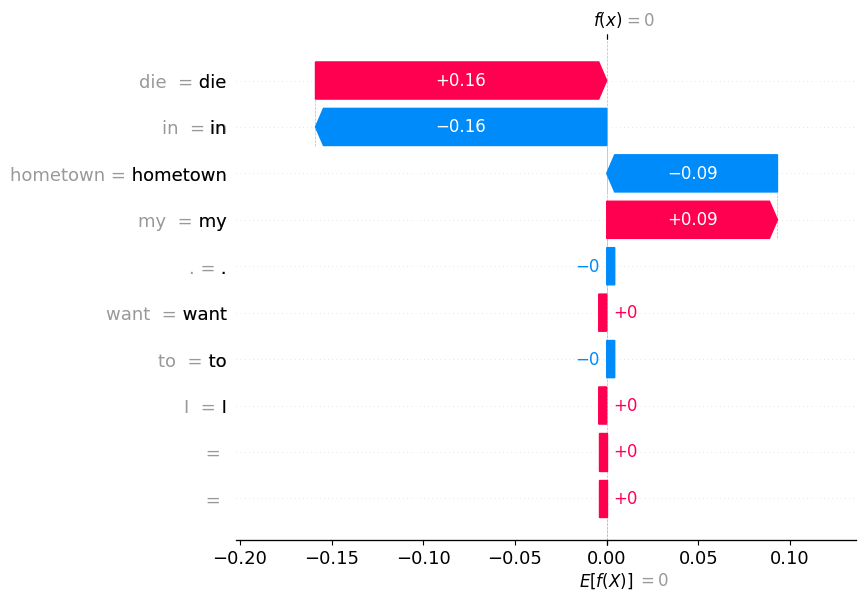

In [49]:
# Display word-level contribution visualization for all sentences
# Explain one sentence only for cleaner visualization
# Non-risky sentence — show risky class contribution
single_text = ["I want to die in my hometown."]
single_shap = explainer(single_text)

print("Sentence:", single_text[0])
print(f"Predicted risky probability: {single_shap[0, :, 1].base_values + single_shap[0, :, 1].values.sum():.4f}")

shap.plots.waterfall(single_shap[0, :, 1], max_display=10)


Sentence: I want to kill myself.
Predicted risky probability: 1.0000


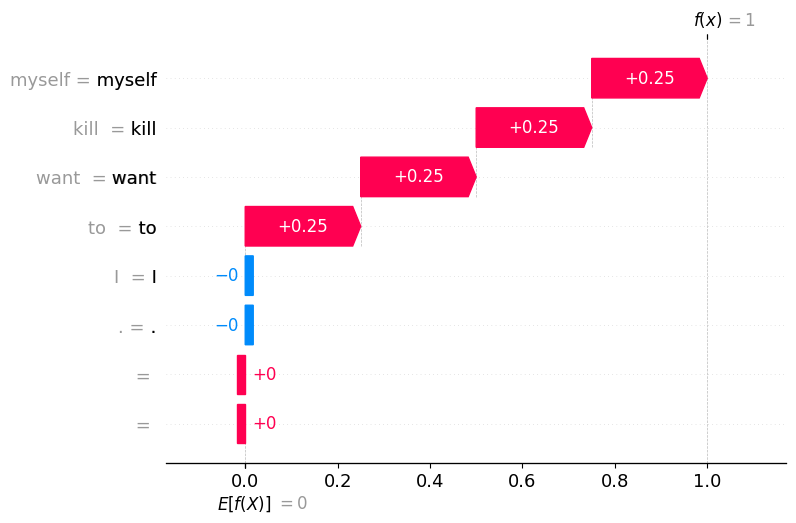

In [50]:
# Compare with a risky sentence
# Risky sentence — show risky class contribution
single_text = ["I want to kill myself."]
single_shap = explainer(single_text)

print("Sentence:", single_text[0])
print(f"Predicted risky probability: {single_shap[0, :, 1].base_values + single_shap[0, :, 1].values.sum():.4f}")

shap.plots.waterfall(single_shap[0, :, 1], max_display=10)

Sentence: I want to eat ice cream.
Predicted risky probability: 0.0000


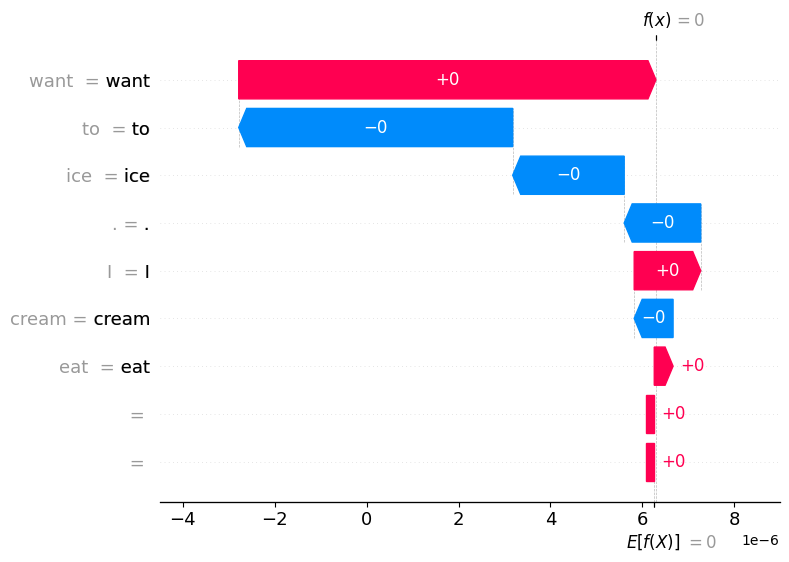

In [51]:
# Compare with a risky sentence
# Risky sentence — show risky class contribution
single_text = ["I want to eat ice cream."]
single_shap = explainer(single_text)

print("Sentence:", single_text[0])
print(f"Predicted risky probability: {single_shap[0, :, 1].base_values + single_shap[0, :, 1].values.sum():.4f}")

shap.plots.waterfall(single_shap[0, :, 1], max_display=10)

Sentence: I want to kill my mom because she make me mad.
Predicted risky probability: 1.0000


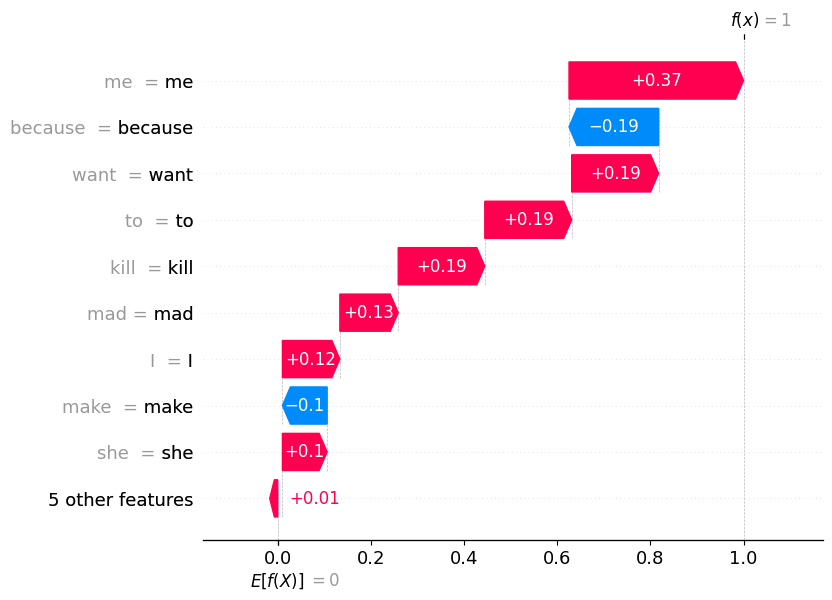

In [52]:
# Compare with a risky sentence
# Risky sentence — show risky class contribution
single_text = ["I want to kill my mom because she make me mad."]
single_shap = explainer(single_text)

print("Sentence:", single_text[0])
print(f"Predicted risky probability: {single_shap[0, :, 1].base_values + single_shap[0, :, 1].values.sum():.4f}")

shap.plots.waterfall(single_shap[0, :, 1], max_display=10)

# ======================================
# EMIRA - MC DROPOUT + OOD EXPERIMENTS
# ======================================

In [53]:
test_sentence = [

    "I crashed onto my bed after work",

    "This exam killed my confidence",

    "The comedian murdered the audience tonight",

    "I no longer want to hurt myself",

    "I recovered from depression",

    "Doing sports can reduce my anxiety",

    # RISKY
    "I feel like everyone would be better without me",

    "I am tired of pretending I am okay",

    "I don't think I can do this anymore",

    "I crashed into bed after work and did not want to wake up ever again",

    "I feel trapped inside my own thoughts",

    "Will life gets easy once I disappear?",

    "Sometimes I feel like someone is watching me"
]


for text in test_sentence:

    result = predict_intent(
        text,
        model,
        tokenizer,
        label_encoder,
        device
    )

    print(f"Text: {text}")
    print(f"Prediction: {result}")
    print("-" * 50)

Text: I crashed onto my bed after work
Prediction: risky
--------------------------------------------------
Text: This exam killed my confidence
Prediction: non-risky
--------------------------------------------------
Text: The comedian murdered the audience tonight
Prediction: non-risky
--------------------------------------------------
Text: I no longer want to hurt myself
Prediction: non-risky
--------------------------------------------------
Text: I recovered from depression
Prediction: non-risky
--------------------------------------------------
Text: Doing sports can reduce my anxiety
Prediction: non-risky
--------------------------------------------------
Text: I feel like everyone would be better without me
Prediction: risky
--------------------------------------------------
Text: I am tired of pretending I am okay
Prediction: risky
--------------------------------------------------
Text: I don't think I can do this anymore
Prediction: risky
-----------------------------------

In [54]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from transformers import RobertaModel

In [55]:
class IntentClassifierMCDropout(nn.Module):

    def __init__(
        self,
        model_name='roberta-base',
        num_labels=2,
        dropout_prob=0.5
    ):
        super(IntentClassifierMCDropout, self).__init__()

        self.roberta = RobertaModel.from_pretrained(model_name)

        self.dropout1 = nn.Dropout(dropout_prob)
        self.dropout2 = nn.Dropout(dropout_prob)

        hidden_size = self.roberta.config.hidden_size

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout_prob),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),

            nn.Linear(128, num_labels)
        )

    def forward(self, input_ids, attention_mask):

        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_output = outputs.last_hidden_state[:, 0, :]

        x = self.dropout1(cls_output)
        x = self.dropout2(x)

        logits = self.classifier(x)

        return logits

In [56]:
# ============================================================
# ENABLE DROPOUT DURING INFERENCE
# ============================================================

def enable_dropout(model):

    for module in model.modules():

        if isinstance(module, nn.Dropout):
            module.train()


In [57]:
# ============================================================
# PREDICTIVE ENTROPY
# ============================================================

def predictive_entropy(probabilities):

    probabilities = np.clip(probabilities, 1e-12, 1.0)

    return -np.sum(probabilities * np.log(probabilities))


In [58]:
# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_model_mc_dropout(
    model,
    train_loader,
    val_loader,
    device,
    epochs=5,
    learning_rate=2e-5
):

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate
    )

    # IMPORTANT FIX
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    best_accuracy = 0
    best_val_loss = float('inf')

    patience = 2

    patience_counter = 0
    best_model_state = None

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    for epoch in range(epochs):

        # =========================
        # TRAIN
        # =========================

        model.train()

        train_loss = 0
        train_correct = 0
        train_total = 0

        for batch in train_loader:

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['intent'].to(device)

            optimizer.zero_grad()

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(logits, labels)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            train_loss += loss.item()

            predictions = torch.argmax(logits, dim=1)

            train_correct += (predictions == labels).sum().item()

            train_total += labels.size(0)

        train_accuracy = train_correct / train_total
        avg_train_loss = train_loss / len(train_loader)

        # =========================
        # VALIDATION
        # =========================

        model.eval()

        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for batch in val_loader:

                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['intent'].to(device)

                logits = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

                loss = criterion(logits, labels)

                val_loss += loss.item()

                predictions = torch.argmax(logits, dim=1)

                val_correct += (predictions == labels).sum().item()

                val_total += labels.size(0)

        val_accuracy = val_correct / val_total
        avg_val_loss = val_loss / len(val_loader)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)

        history['train_acc'].append(train_accuracy)
        history['val_acc'].append(val_accuracy)

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss : {avg_train_loss:.4f}")
        print(f"Val Loss   : {avg_val_loss:.4f}")
        print(f"Train Acc  : {train_accuracy:.4f}")
        print(f"Val Acc    : {val_accuracy:.4f}")

        # SAVE BEST MODEL
        if avg_val_loss < best_val_loss:

          best_val_loss = avg_val_loss

          best_accuracy = val_accuracy

          import copy

          best_model_state = copy.deepcopy(model.state_dict())

          patience_counter = 0

          print(f"✓ New best model saved!")

        else:

            patience_counter += 1

            print(f"No improvement. Patience: {patience_counter}/{patience}")

            if patience_counter >= patience:

                print("\nEarly stopping triggered!")

                break

    return best_model_state, best_accuracy, history


In [59]:
# ============================================================
# MC DROPOUT PREDICTION
# ============================================================

def predict_with_mc_dropout(
    text,
    model,
    tokenizer,
    device,
    max_len=128,
    mc_passes=50
):

    encoding = tokenizer(
        text = preprocess_text(text),
        truncation=True,
        padding='max_length',
        max_length=max_len,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    model.eval()

    # IMPORTANT
    enable_dropout(model)

    all_probs = []

    with torch.no_grad():

        for _ in range(mc_passes):

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            temperature = 1.5

            scaled_logits = logits / temperature

            probs = F.softmax(scaled_logits, dim=1)

            all_probs.append(
                probs.cpu().numpy()[0]
            )

    all_probs = np.array(all_probs)
        # ====================================================
    # UNCERTAINTY METRICS
    # ====================================================

    mean_probs = np.mean(all_probs, axis=0)

    confidence = np.max(mean_probs)

    predicted_class = np.argmax(mean_probs)

    uncertainty = np.mean(np.var(all_probs, axis=0))

    return {
        'prediction': predicted_class,
        'confidence': float(confidence),
        'uncertainty': float(uncertainty),
        'mean_probs': mean_probs
    }

In [60]:
# ============================================================
# LABEL MAPPING
# ============================================================

label_map = {
    0: "non-risky",
    1: "risky"
}



In [61]:
# ============================================================
# TEST FUNCTION
# ============================================================

def test_mc_dropout(
    sentences,
    model,
    tokenizer,
    device
):

    for text in sentences:

        result = predict_with_mc_dropout(
            text=text,
            model=model,
            tokenizer=tokenizer,
            device=device,
            mc_passes=30
        )

        print("=" * 60)

        print(f"Text        : {text}")

        print(f"Prediction  : {label_map[result['prediction']]}")

        print(f"Confidence  : {result['confidence']:.4f}")

        print(f"Uncertainty : {result['uncertainty']:.6f}")


In [62]:
# ============================================================
# CREATE MODEL
# ============================================================

model3 = IntentClassifierMCDropout(
    model_name='roberta-base',
    num_labels=2,
    dropout_prob=0.5
)

import gc
import torch

gc.collect()

torch.cuda.empty_cache()

print(torch.cuda.memory_summary(device=None, abbreviated=True))

model3.to(device)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |   1940 MiB |   2916 MiB |   2987 GiB |   2985 GiB |
|---------------------------------------------------------------------------|
| Active memory         |   1940 MiB |   2916 MiB |   2987 GiB |   2985 GiB |
|---------------------------------------------------------------------------|
| Requested memory      |   1919 MiB |   2870 MiB |   2947 GiB |   2945 GiB |
|---------------------------------------------------------------

IntentClassifierMCDropout(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (Layer

In [63]:
# ============================================================
# TRAIN MODEL
# ============================================================

best_model_state3, best_accuracy3, history3 = train_model_mc_dropout(
    model=model3,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=5
)

model3.load_state_dict(best_model_state3)



Epoch 1/5
Train Loss : 0.6866
Val Loss   : 0.5845
Train Acc  : 0.5388
Val Acc    : 0.8268
✓ New best model saved!

Epoch 2/5
Train Loss : 0.3492
Val Loss   : 0.2017
Train Acc  : 0.9438
Val Acc    : 1.0000
✓ New best model saved!

Epoch 3/5
Train Loss : 0.2238
Val Loss   : 0.2031
Train Acc  : 1.0000
Val Acc    : 1.0000
No improvement. Patience: 1/2

Epoch 4/5
Train Loss : 0.2227
Val Loss   : 0.2262
Train Acc  : 0.9989
Val Acc    : 0.9921
No improvement. Patience: 2/2

Early stopping triggered!


<All keys matched successfully>

In [64]:
# ============================================================
# TEST SENTENCES
# ============================================================

test_sentences = [

    # NON-RISKY
    "I crashed onto my bed after work",

    "This exam killed my confidence",

    "The comedian murdered the audience tonight",

    "I no longer want to hurt myself",

    "I recovered from depression",

    "Doing sports can reduce my anxiety",

    # RISKY
    "I feel like everyone would be better without me",

    "I am tired of pretending I am okay",

    "I don't think I can do this anymore",

    "I crashed into bed after work and did not want to wake up ever again",

    "I feel trapped inside my own thoughts",

    "Will life gets easy once I disappear?",

    "Sometimes I feel like someone is watching me"
]


In [65]:
# ============================================================
# RUN TEST
# ============================================================

test_mc_dropout(
    sentences=test_sentences,
    model=model3,
    tokenizer=tokenizer,
    device=device
)

Text        : I crashed onto my bed after work
Prediction  : non-risky
Confidence  : 0.8447
Uncertainty : 0.005316
Text        : This exam killed my confidence
Prediction  : non-risky
Confidence  : 0.8847
Uncertainty : 0.003171
Text        : The comedian murdered the audience tonight
Prediction  : non-risky
Confidence  : 0.8733
Uncertainty : 0.004446
Text        : I no longer want to hurt myself
Prediction  : non-risky
Confidence  : 0.8394
Uncertainty : 0.007894
Text        : I recovered from depression
Prediction  : non-risky
Confidence  : 0.8268
Uncertainty : 0.011116
Text        : Doing sports can reduce my anxiety
Prediction  : non-risky
Confidence  : 0.8408
Uncertainty : 0.005943
Text        : I feel like everyone would be better without me
Prediction  : risky
Confidence  : 0.6289
Uncertainty : 0.052205
Text        : I am tired of pretending I am okay
Prediction  : non-risky
Confidence  : 0.6767
Uncertainty : 0.072226
Text        : I don't think I can do this anymore
Prediction  :

In [66]:
extra_test = [
    "I think everyone secretly wishes I would just vanish one day",
    "The meeting killed my motivation but I still have work to finish",
    "I keep wondering if people would notice if I suddenly stopped existing",
    "That roller coaster drop nearly gave me a heart attack",
    "I am so mentally exhausted that disappearing forever sounds comforting",
    "I dont want to cut myself anymore now that I am much more mentally stable",
    "I dont want to cut myself anymore",
    "I thought I was getting better but I dont want to live",
    "I hope I can control my anger"
    ]

In [67]:
# ============================================================
# RUN TEST
# ============================================================

test_mc_dropout(
    sentences=extra_test,
    model=model3,
    tokenizer=tokenizer,
    device=device
)

Text        : I think everyone secretly wishes I would just vanish one day
Prediction  : risky
Confidence  : 0.8307
Uncertainty : 0.005165
Text        : The meeting killed my motivation but I still have work to finish
Prediction  : non-risky
Confidence  : 0.8719
Uncertainty : 0.005500
Text        : I keep wondering if people would notice if I suddenly stopped existing
Prediction  : risky
Confidence  : 0.8390
Uncertainty : 0.005137
Text        : That roller coaster drop nearly gave me a heart attack
Prediction  : risky
Confidence  : 0.8232
Uncertainty : 0.006672
Text        : I am so mentally exhausted that disappearing forever sounds comforting
Prediction  : risky
Confidence  : 0.8458
Uncertainty : 0.006340
Text        : I dont want to cut myself anymore now that I am much more mentally stable
Prediction  : non-risky
Confidence  : 0.8349
Uncertainty : 0.004100
Text        : I dont want to cut myself anymore
Prediction  : non-risky
Confidence  : 0.8559
Uncertainty : 0.003983
Text       

ID Test Results
Accuracy : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report:

              precision    recall  f1-score   support

   non-risky       1.00      1.00      1.00       187
       risky       1.00      1.00      1.00       194

    accuracy                           1.00       381
   macro avg       1.00      1.00      1.00       381
weighted avg       1.00      1.00      1.00       381



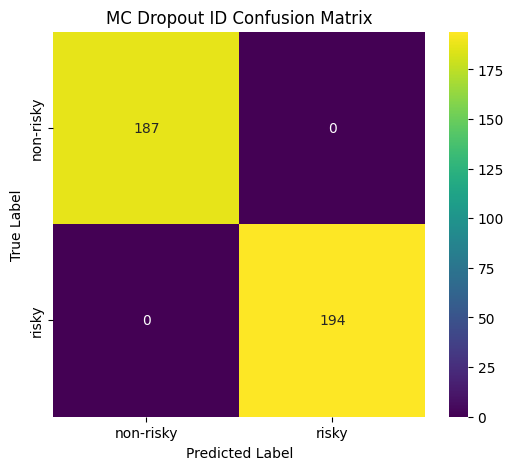

In [68]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# ID TEST EVALUATION
# ==========================================

model3.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['intent'].to(device)

        logits = model3(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# METRICS
acc = accuracy_score(all_labels, all_preds)

precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average='weighted'
)

print("ID Test Results")
print(f"Accuracy : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report:\n")

print(classification_report(
    all_labels,
    all_preds,
    target_names=['non-risky', 'risky']
))

# CONFUSION MATRIX
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=['non-risky', 'risky'],
    yticklabels=['non-risky', 'risky']
)

plt.title("MC Dropout ID Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

OOD Results
Accuracy : 0.5333
Precision : 0.5242
Recall    : 0.5333
F1 Score  : 0.5065

Classification Report:

              precision    recall  f1-score   support

   non-risky       0.55      0.75      0.63        80
       risky       0.50      0.29      0.36        70

    accuracy                           0.53       150
   macro avg       0.52      0.52      0.50       150
weighted avg       0.52      0.53      0.51       150



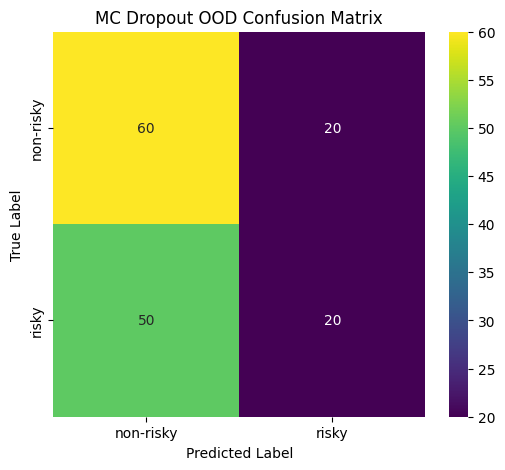

In [69]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# ==========================================
# OOD EVALUATION
# ==========================================
ood_preds = []
ood_labels = []

label_map_reverse = {

    'non-risky': 0,
    'risky': 1
}

for _, row in df_ood.iterrows():

    result = predict_with_mc_dropout(

        text=row['text'],
        model=model3,
        tokenizer=tokenizer,
        device=device
    )

    pred = result['prediction']

    ood_preds.append(pred)

    ood_labels.append(

        label_map_reverse[
            row['gold_label']
        ]
    )

# METRICS
ood_acc = accuracy_score(
    ood_labels,
    ood_preds
)

precision, recall, f1, _ = precision_recall_fscore_support(
    ood_labels,
    ood_preds,
    average='weighted'
)

print("OOD Results")
print(f"Accuracy : {ood_acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report:\n")

print(classification_report(
    ood_labels,
    ood_preds,
    target_names=['non-risky', 'risky']
))

# CONFUSION MATRIX
cm = confusion_matrix(ood_labels, ood_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=['non-risky', 'risky'],
    yticklabels=['non-risky', 'risky']
)

plt.title("MC Dropout OOD Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [70]:
#OOD Category Analysis
from sklearn.metrics import f1_score

label_map_reverse = {

    'non-risky': 0,
    'risky': 1
}

category_results = []

categories = df_ood['category'].unique()

for cat in categories:

    subset = df_ood[
        df_ood['category'] == cat
    ]

    preds = []
    labels = []

    for _, row in subset.iterrows():

        result = predict_with_mc_dropout(

            text=row['text'],
            model=model3,
            tokenizer=tokenizer,
            device=device
        )

        preds.append(
            result['prediction']
        )

        labels.append(

            label_map_reverse[
                row['gold_label']
            ]
        )

    acc = accuracy_score(labels, preds)

    macro_f1 = f1_score(
        labels,
        preds,
        average='macro'
    )

    category_results.append({

        "category": cat,
        "count": len(subset),
        "accuracy": acc,
        "macro_f1": macro_f1
    })

category_df = pd.DataFrame(category_results)

print("OOD Category Metrics:")

display(category_df)

OOD Category Metrics:


,category,count,accuracy,macro_f1
0,negation,30,0.700000,0.630643
1,temporal,30,0.266667,0.253394
2,negation_temporal,30,0.566667,0.466484
3,figurative,30,0.633333,0.622857
4,ambiguous,30,0.533333,0.524887


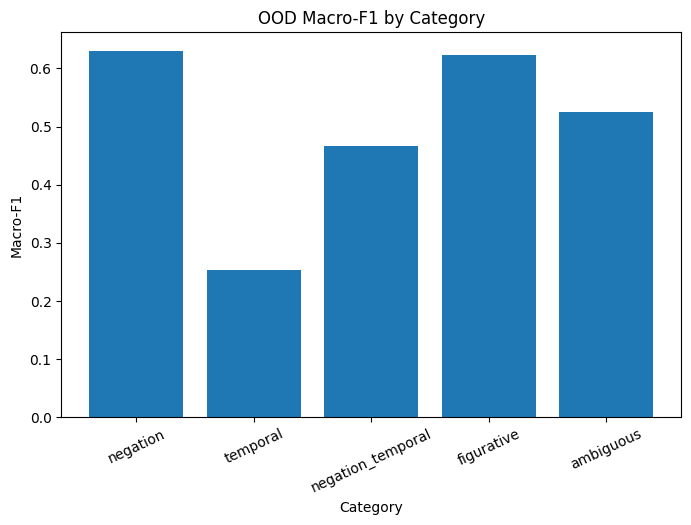

In [71]:
#Bar Chart

plt.figure(figsize=(8,5))

plt.bar(
    category_df['category'],
    category_df['macro_f1']
)

plt.title("OOD Macro-F1 by Category")
plt.xlabel("Category")
plt.ylabel("Macro-F1")

plt.xticks(rotation=25)

plt.show()

In [72]:
#SHAP Analysis

import shap
import numpy as np

def predict_proba_mc(texts):

    probs_all = []

    for text in texts:

        encoding = tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        )

        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        enable_dropout(model3)

        mc_probs = []

        with torch.no_grad():

            for _ in range(20):

                logits = model3(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

                probs = torch.softmax(
                    logits / 1.5,
                    dim=1
                )

                mc_probs.append(
                    probs.cpu().numpy()[0]
                )

        mean_probs = np.mean(
            mc_probs,
            axis=0
        )

        probs_all.append(mean_probs)

    return np.array(probs_all)

In [73]:
explainer = shap.Explainer(
    predict_proba_mc,
    tokenizer
)

In [74]:
sentences = [

    "I no longer want to hurt myself.",

    " I dont want to cut myself anymore.",

    "I want to die in my hometown."
]

In [75]:
shap_values = explainer(sentences)

  0%|          | 0/90 [00:00<?, ?it/s]

PartitionExplainer explainer:  33%|███▎      | 1/3 [00:00<?, ?it/s]

  0%|          | 0/90 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 3/3 [01:03<00:00, 15.95s/it]

  0%|          | 0/90 [00:00<?, ?it/s]

PartitionExplainer explainer: 4it [01:34, 31.54s/it]


Sentence 1: I no longer want to hurt myself.
Prediction: non-risky
Non-risky probability: 0.8087
Risky probability    : 0.1913

SHAP waterfall explanation for risky class:



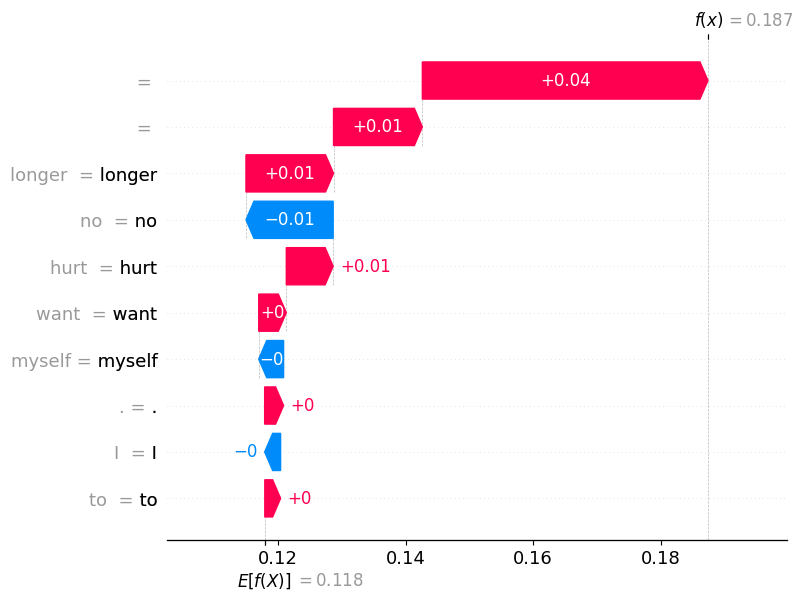

Sentence 2:  I dont want to cut myself anymore.
Prediction: non-risky
Non-risky probability: 0.8441
Risky probability    : 0.1559

SHAP waterfall explanation for risky class:



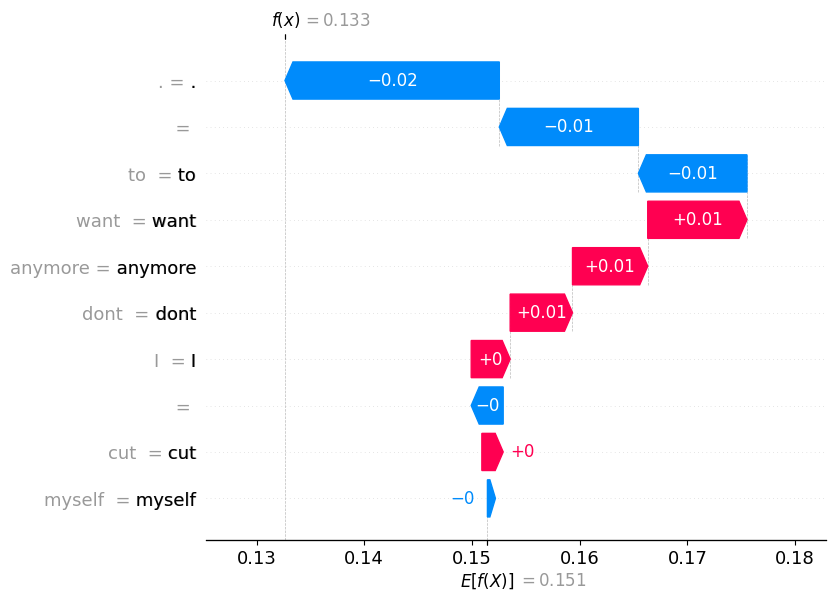

Sentence 3: I want to die in my hometown.
Prediction: non-risky
Non-risky probability: 0.7750
Risky probability    : 0.2250

SHAP waterfall explanation for risky class:



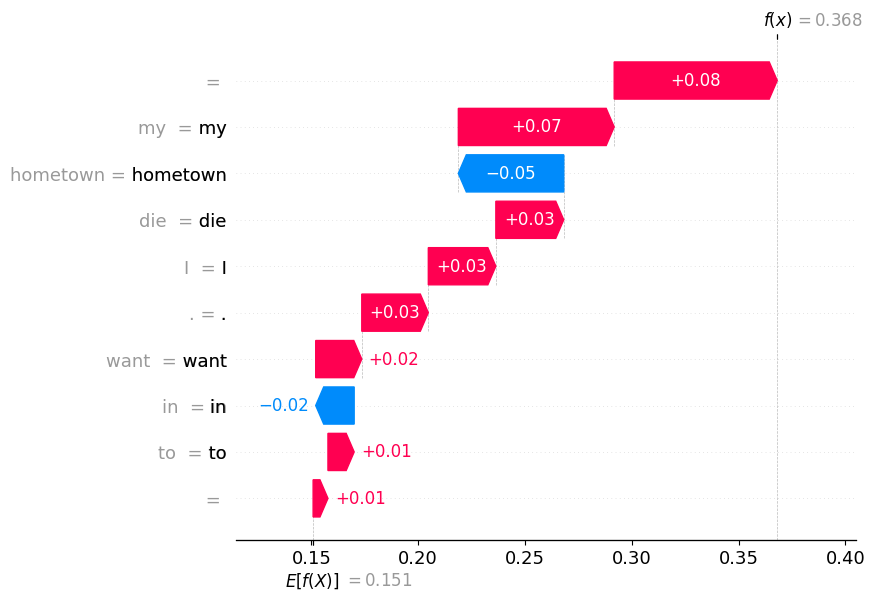

In [76]:
for i, text in enumerate(sentences):

    probs = predict_proba_mc([text])[0]

    pred_class = np.argmax(probs)

    print("=" * 90)

    print(f"Sentence {i+1}: {text}")

    print("=" * 90)

    print(
        "Prediction:",
        "risky" if pred_class == 1 else "non-risky"
    )

    print(
        f"Non-risky probability: {probs[0]:.4f}"
    )

    print(
        f"Risky probability    : {probs[1]:.4f}"
    )

    print("\nSHAP waterfall explanation for risky class:\n")

    shap.plots.waterfall(
        shap_values[i, :, 1],
        max_display=10
    )

In [77]:
comparison_df = pd.DataFrame({

    "experiment_id": ["E1", "E2"],

    "experiment_name": [

        "RoBERTa Fine-Tuned Baseline",

        "RoBERTa + MC Dropout"
    ],

    "id_accuracy": [
        baseline_accuracy,
        mc_accuracy
    ],

    "id_macro_f1": [
        baseline_f1,
        mc_f1
    ],

    "ood_accuracy": [
        baseline_ood_acc,
        ood_acc
    ],

    "ood_macro_f1": [
        baseline_ood_f1,
        ood_f1
    ],

    "id_ood_gap": [

        baseline_accuracy - baseline_ood_acc,

        mc_accuracy - ood_acc
    ],

    "ood_confident_wrong_count": [

        baseline_overconf_wrong,

        mc_overconf_wrong
    ]
})

display(comparison_df)

NameError: name 'baseline_accuracy' is not defined